In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from generators.echo_state_generator import EchoStateNetwork
from utils.config_utils import load_config
import torch
from inference_visualization import download_model_and_config, generate_series_using_dataset

In [4]:
run_id = 's2gk8uag'

In [6]:
from training.train_decoder import load_model

model_path, config = download_model_and_config(run_id)
config['esn_store_state'] = True
config['dataset']['val']['num_series'] = 1_000
model = load_model(model_path, config)
model.to('cuda')
dataloader = generate_series_using_dataset(config, num_series=1)

training decoder


wandb:   1 of 1 files downloaded.  
/home/wojciech/private/magisterka/TFTS/training/train_decoder.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.loa

Downloaded model: /home/wojciech/private/magisterka/TFTS/notebooks/artifacts/model-s2gk8uag:v76/model.ckpt


In [7]:
dataset_config = config.get('dataset', {})
esn_config = dataset_config.get('esn', {})

# Dataset parameters could come from either train or val sections,
# depending on how this instance is being used
# We'll check for both but prioritize train
train_config = dataset_config.get('train', {})
val_config = dataset_config.get('val', {})

# ESN parameters
n_input = esn_config.get('n_input', 0)
n_reservoir = esn_config.get('n_reservoir', 0)
spectral_radius = esn_config.get('spectral_radius', 0)
sparsity = esn_config.get('sparsity', 0)
input_scaling = esn_config.get('input_scaling', 0)
leak_rate = esn_config.get('leak_rate', 0)
esn_id = esn_config.get('esn_id', 0)
roll_every = esn_config.get('roll_every', 1)

# Store ESN parameters for logging/reproducibility
esn_params = {
    'n_input': n_input,
    'n_reservoir': n_reservoir,
    'spectral_radius': spectral_radius,
    'sparsity': sparsity,
    'input_scaling': input_scaling,
    'leak_rate': leak_rate,
    'random_state_torch': esn_id,
}

In [8]:
esn = EchoStateNetwork(**esn_params)

In [9]:
esn.reset_state()

In [76]:
def get_output_distribution(esn, inference_estimation_experiments, seq_len, bins_count):
    result_vectors = []
    esn.reset_state()
    real_outputs = []
    for _ in range(seq_len):
        result_vectors.append(esn.infer_but_no_state_change(torch.randn(1, inference_estimation_experiments)))
        real_outputs.append(esn(torch.randn(1)))
    max_val = torch.max(torch.cat(result_vectors, dim=1))
    min_val = torch.min(torch.cat(result_vectors, dim=1))
    bins = torch.linspace(min_val, max_val, bins_count)
    histograms = []
    for vector in result_vectors:
        hist, _ = torch.histogram(vector, bins=bins)
        histograms.append(hist)
    return torch.vstack(histograms), (np.array(real_outputs) - min_val.item()) / (max_val.item() - min_val.item()) * bins_count, max_val.item(), min_val.item()

In [77]:
def transform_to_coords_space(data, min, max):
    return (data / 100 * (max - min)) + min

def inverse_transform_to_coords_space(data, min, max):
    return (data - min) / (max - min) * 100

In [78]:
hists, output, maxv, minv = get_output_distribution(esn, 10000, 100, 100)

In [79]:
inp = torch.tensor(transform_to_coords_space(output, minv, maxv)[:-1], dtype=torch.float32)
inp = inp.to('cuda').reshape(1, -1, 1)
prediction = inverse_transform_to_coords_space(model(inp), minv, maxv).detach().cpu().numpy().flatten()

In [80]:
prediction = np.concatenate([np.array([50]), prediction])

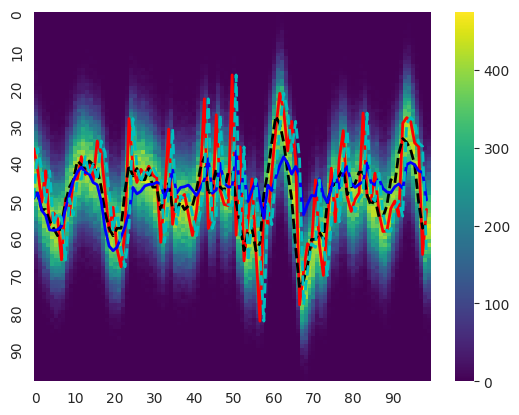

In [89]:
import seaborn as sns
sns.heatmap(hists.T.cpu().numpy(), cmap='viridis', cbar=True, xticklabels=10, yticklabels=10)
plt.plot(output, 'r-', linewidth=2, label='Real Outputs')
plt.plot(torch.argmax(hists, axis=1).cpu().numpy(), 'k--', linewidth=2, label='Predicted Outputs')
plt.plot(prediction, 'b-', linewidth=2, label='Model Predictions')
plt.plot(np.concatenate([np.array([50]), output[:-1]]), 'c--', linewidth=2, label='Previous Output Prediction')

In [93]:
preds_ground_truth = transform_to_coords_space(torch.argmax(hists, axis=1).cpu().numpy(), minv, maxv)
output_coords = transform_to_coords_space(output, minv, maxv)
prediction_coords = transform_to_coords_space(prediction, minv, maxv)
just_predict_previous = np.concatenate([np.array([0]), output_coords[:-1]])
just_predict_previous_gt = np.concatenate([np.array([0]), preds_ground_truth[:-1]])

In [94]:
gt_r2 = 1 - np.sum((preds_ground_truth - output_coords) ** 2) / np.sum(output_coords**2)
vs_real_r2 = 1 - np.sum((prediction_coords - output_coords) ** 2) / np.sum(output_coords**2)
vs_gt_r2 = 1 - np.sum((preds_ground_truth - prediction_coords) ** 2) / np.sum(preds_ground_truth**2)
just_predict_previous_r2 = 1 - np.sum((just_predict_previous - output_coords) ** 2) / np.sum(output_coords**2)
just_predict_previous_vs_gt_r2 = 1 - np.sum((preds_ground_truth - just_predict_previous) ** 2) / np.sum(preds_ground_truth**2)
just_previous_gt_vs_real = 1 - np.sum((output_coords - just_predict_previous_gt) ** 2) / np.sum(output_coords**2)
just_previous_gt_vs_gt = 1 - np.sum((preds_ground_truth - just_predict_previous_gt) ** 2) / np.sum(preds_ground_truth**2)

In [95]:
gt_r2, vs_real_r2, vs_gt_r2, just_predict_previous_r2, just_predict_previous_vs_gt_r2, just_previous_gt_vs_real, just_previous_gt_vs_gt

(0.5358560259346883,
 0.13863036146186203,
 0.23759788910486968,
 -0.29683502520611627,
 -0.8360464565141548,
 0.5327620987984756,
 0.7248989415189424)